# F1 — EDA Titanic: Exploración Inicial Reproducible
## MCDI503 Exploración Inteligente para la Ciencia de Datos | Grupo 4

---

### § I — Identificación del proyecto

| Campo | Detalle |
|---|---|
| **Curso** | MCDI503 — Exploración Inteligente para la Ciencia de Datos |
| **Fase** | Fase 1 — Avance sumativo |
| **Dataset** | Titanic (seaborn built-in) |
| **Propósito** | Implementar el primer ciclo de EDA reproducible: carga, revisión, exploración preliminar, decisiones iniciales y hallazgos exploratorios del dataset Titanic. |
| **Integrantes** | Marcelo Corro Araya · Camila Quezada · Catalina Troncoso |
| **Fecha** | Septiembre 2026 |

> **Nota de reproducibilidad:** este notebook se ejecuta completamente desde cero con *Kernel → Restart & Run All*. El dataset se carga directamente desde la librería `seaborn`, sin dependencias de archivos externos.

---
## § II — Contexto y objetivo exploratorio

### § II.1 — Contexto del problema

El hundimiento del RMS Titanic en abril de 1912 es uno de los desastres marítimos más documentados
de la historia. De los 2.224 pasajeros y tripulantes a bordo, sobrevivieron aproximadamente 710
personas (≈32%). El acceso a los botes salvavidas estuvo fuertemente condicionado por factores
socioeconómicos, demográficos y operativos, lo que convierte a este dataset en un caso de estudio
canónico para el análisis exploratorio de datos: presenta una variable objetivo binaria clara
(`survived`), variables de tipo mixto (numéricas y categóricas), valores faltantes estructurales
y patrones de relación entre variables de distinta naturaleza.

El dataset **Titanic** disponible en `seaborn` contiene 891 observaciones y 15 variables que
describen a cada pasajero: clase de viaje, sexo, edad, número de familiares a bordo, tarifa
pagada, puerto de embarque y si sobrevivió o no. Su riqueza analítica lo hace ideal para cubrir
la totalidad del recorrido técnico de las fases del proyecto.

### § II.2 — Objetivo exploratorio

> Comprender la estructura general del dataset Titanic, identificar sus características técnicas
> (tipos de datos, valores faltantes, distribuciones), y detectar patrones iniciales de
> asociación entre las variables y la supervivencia, como base reproducible para las fases
> posteriores del proyecto.

### § II.3 — Preguntas exploratorias iniciales

1. ¿Cuál es la distribución de supervivientes y no supervivientes en el dataset?
2. ¿Qué variables presentan valores faltantes y en qué magnitud?
3. ¿Existen diferencias en la tasa de supervivencia según sexo, clase de viaje y edad?
4. ¿Cómo se distribuye la variable `age` y qué implicaciones tiene para el análisis?
5. ¿Hay variables redundantes o derivadas que puedan simplificarse para el análisis?


---
## § III — Carga y revisión inicial de datos


In [1]:
# § III.1 — Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("Librerías cargadas correctamente.")
print(f"  pandas  {pd.__version__}")
print(f"  numpy   {np.__version__}")
print(f"  seaborn {sns.__version__}")


Librerías cargadas correctamente.
  pandas  3.0.3
  numpy   2.4.6
  seaborn 0.13.2


In [2]:
# § III.2 — Carga del dataset desde seaborn
df = sns.load_dataset('titanic')

print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head(5)


Dataset cargado: 891 filas × 15 columnas


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# § III.3 — Tipos de datos y estructura general
print("=== TIPOS DE DATOS ===")
print(df.dtypes)
print(f"\nVariables numéricas : {df.select_dtypes(include='number').columns.tolist()}")
print(f"Variables categóricas: {df.select_dtypes(include='object').columns.tolist()}")
print(f"Variables booleanas  : {df.select_dtypes(include='bool').columns.tolist()}")


=== TIPOS DE DATOS ===
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

Variables numéricas : ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Variables categóricas: ['sex', 'embarked', 'who', 'embark_town', 'alive']
Variables booleanas  : ['adult_male', 'alone']


=== VALORES FALTANTES ===
             Faltantes  Porcentaje
deck               688     77.2200
age                177     19.8700
embarked             2      0.2200
embark_town          2      0.2200


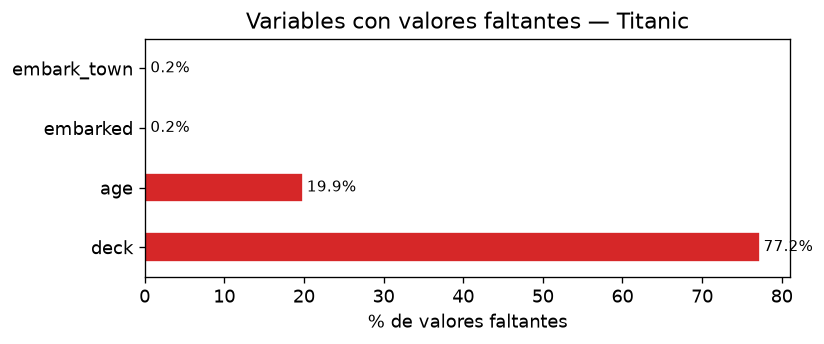

Figura guardada: f1_missing_values.png


In [4]:
# § III.4 — Diagnóstico de valores faltantes
missing = pd.DataFrame({
    'Faltantes' : df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).query('Faltantes > 0').sort_values('Porcentaje', ascending=False)

print("=== VALORES FALTANTES ===")
print(missing.to_string())

fig, ax = plt.subplots(figsize=(7, 3))
missing['Porcentaje'].plot(kind='barh', ax=ax, color='#d62728', edgecolor='white')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Variables con valores faltantes — Titanic')
for i, v in enumerate(missing['Porcentaje']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../../reports/figures/f1_missing_values.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_missing_values.png")


In [5]:
# § III.5 — Primera caracterización global
print("=== RESUMEN .info() ===")
df.info()
print()
print(f"Observaciones (filas) : {df.shape[0]}")
print(f"Variables (columnas)  : {df.shape[1]}")
print(f"Memoria estimada      : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")


=== RESUMEN .info() ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB

Observaciones (filas) : 891
Variables (columnas)  : 15
Memoria estim

**Observaciones §III:**
- El dataset contiene **891 observaciones y 15 variables**.
- Se detectan **3 variables con valores faltantes**: `age` (177, 19.9%), `deck` (688, 77.2%)
  y `embarked` / `embark_town` (2, 0.2%).
- `deck` tiene un porcentaje de faltantes tan alto que su uso en esta fase es limitado.
- Los tipos de datos son coherentes con el dominio: `age` y `fare` como float, `survived` y
  `pclass` como enteros, variables categóricas en object.


---
## § IV — Exploración preliminar


In [6]:
# § IV.1 — Estadísticos descriptivos: variables numéricas
print("=== ESTADÍSTICOS DESCRIPTIVOS — VARIABLES NUMÉRICAS ===")
df.describe().T.round(3)


=== ESTADÍSTICOS DESCRIPTIVOS — VARIABLES NUMÉRICAS ===


,count,mean,std,min,25%,50%,75%,max
survived,891.0000,0.3840,0.4870,0.0000,0.0000,0.0000,1.0000,1.0000
pclass,891.0000,2.3090,0.8360,1.0000,2.0000,3.0000,3.0000,3.0000
age,714.0000,29.6990,14.5260,0.4200,20.1250,28.0000,38.0000,80.0000
sibsp,891.0000,0.5230,1.1030,0.0000,0.0000,0.0000,1.0000,8.0000
parch,891.0000,0.3820,0.8060,0.0000,0.0000,0.0000,0.0000,6.0000
fare,891.0000,32.2040,49.6930,0.0000,7.9100,14.4540,31.0000,512.3290


=== DISTRIBUCIÓN DE 'survived' ===
  No sobrevivió (0):  549  (61.6%)
  Sobrevivió (1):  342  (38.4%)


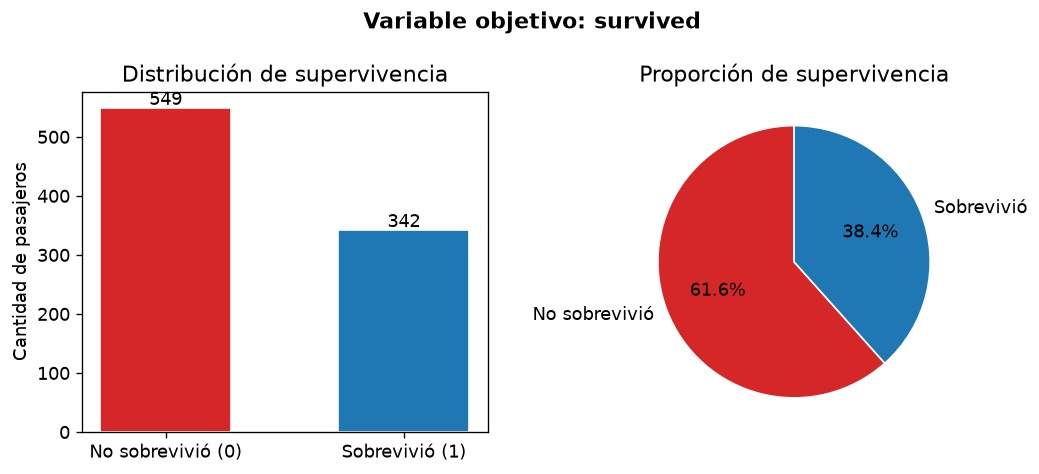

Figura guardada: f1_distribucion_survived.png


In [7]:
# § IV.2 — Distribución de la variable objetivo: survived
conteo = df['survived'].value_counts()
pct    = df['survived'].value_counts(normalize=True) * 100

print("=== DISTRIBUCIÓN DE 'survived' ===")
for k, v in conteo.items():
    label = 'Sobrevivió' if k == 1 else 'No sobrevivió'
    print(f"  {label} ({k}): {v:4d}  ({pct[k]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Barplot
axes[0].bar(['No sobrevivió (0)', 'Sobrevivió (1)'], conteo.values,
            color=['#d62728', '#1f77b4'], edgecolor='white', width=0.55)
axes[0].set_title('Distribución de supervivencia')
axes[0].set_ylabel('Cantidad de pasajeros')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11)

# Pie
axes[1].pie(conteo.values, labels=['No sobrevivió', 'Sobrevivió'],
            colors=['#d62728', '#1f77b4'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Proporción de supervivencia')

plt.suptitle('Variable objetivo: survived', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/figures/f1_distribucion_survived.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_distribucion_survived.png")


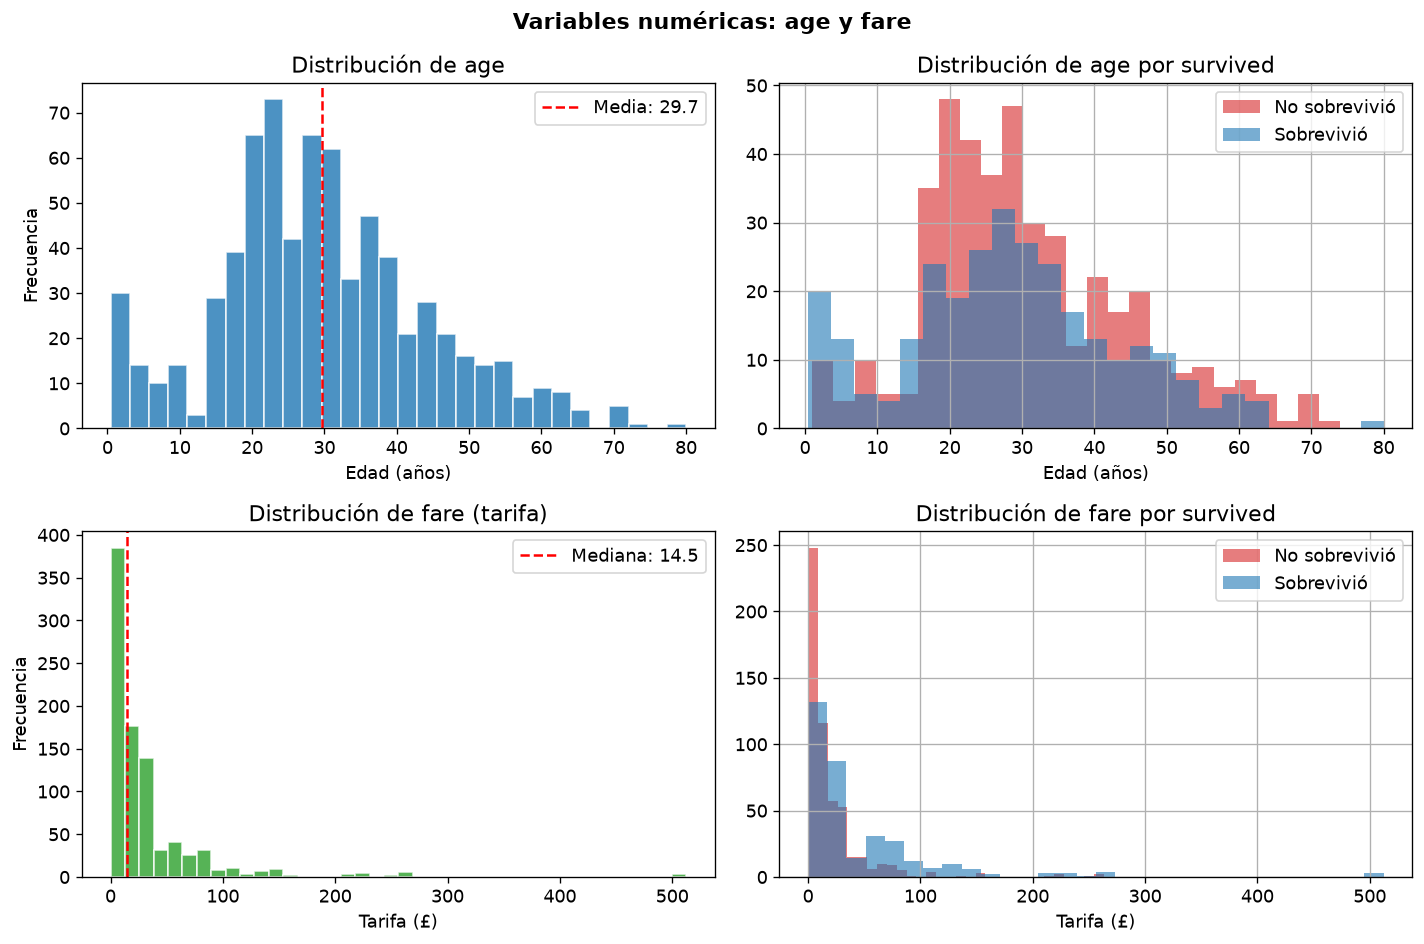

Figura guardada: f1_numericas_age_fare.png


In [8]:
# § IV.3 — Distribución de variables numéricas clave: age y fare
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# age
axes[0, 0].hist(df['age'].dropna(), bins=30, color='#1f77b4', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Distribución de age')
axes[0, 0].set_xlabel('Edad (años)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].axvline(df['age'].mean(), color='red', linestyle='--',
                   label=f"Media: {df['age'].mean():.1f}")
axes[0, 0].legend()

# age por survived
df[df['survived'] == 0]['age'].dropna().hist(
    ax=axes[0, 1], bins=25, alpha=0.6, color='#d62728', label='No sobrevivió')
df[df['survived'] == 1]['age'].dropna().hist(
    ax=axes[0, 1], bins=25, alpha=0.6, color='#1f77b4', label='Sobrevivió')
axes[0, 1].set_title('Distribución de age por survived')
axes[0, 1].set_xlabel('Edad (años)')
axes[0, 1].legend()

# fare
axes[1, 0].hist(df['fare'].dropna(), bins=40, color='#2ca02c', edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Distribución de fare (tarifa)')
axes[1, 0].set_xlabel('Tarifa (£)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].axvline(df['fare'].median(), color='red', linestyle='--',
                   label=f"Mediana: {df['fare'].median():.1f}")
axes[1, 0].legend()

# fare por survived
df[df['survived'] == 0]['fare'].hist(
    ax=axes[1, 1], bins=30, alpha=0.6, color='#d62728', label='No sobrevivió')
df[df['survived'] == 1]['fare'].hist(
    ax=axes[1, 1], bins=30, alpha=0.6, color='#1f77b4', label='Sobrevivió')
axes[1, 1].set_title('Distribución de fare por survived')
axes[1, 1].set_xlabel('Tarifa (£)')
axes[1, 1].legend()

plt.suptitle('Variables numéricas: age y fare', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/figures/f1_numericas_age_fare.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_numericas_age_fare.png")


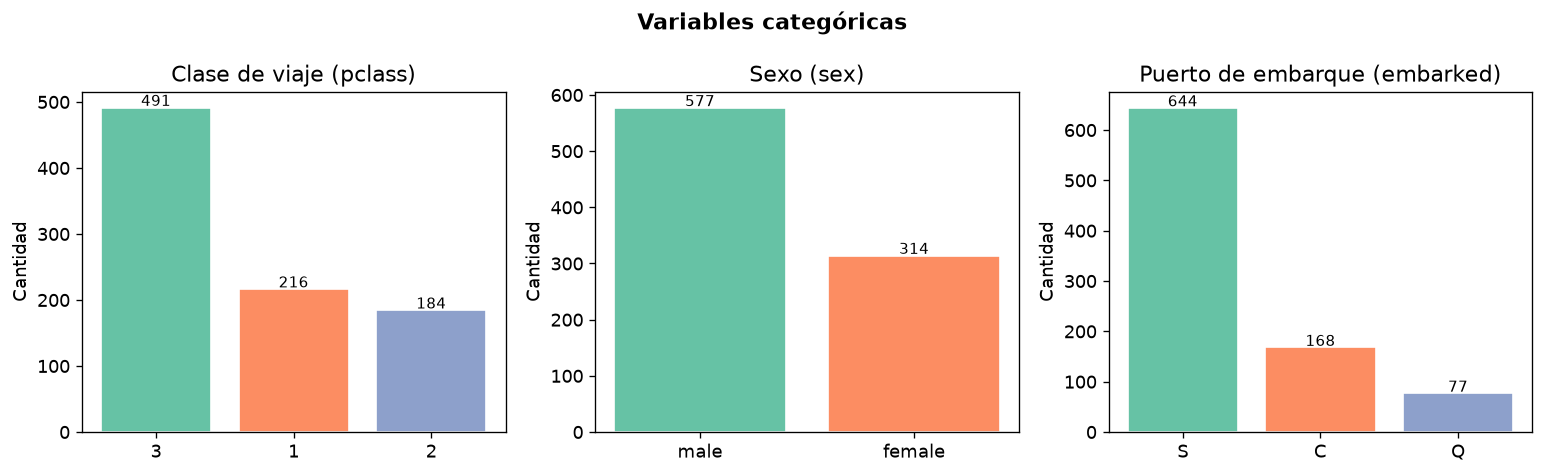

Figura guardada: f1_categoricas.png


In [9]:
# § IV.4 — Distribución de variables categóricas clave
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col, title in zip(
    axes,
    ['pclass', 'sex', 'embarked'],
    ['Clase de viaje (pclass)', 'Sexo (sex)', 'Puerto de embarque (embarked)']
):
    vc = df[col].value_counts()
    ax.bar(vc.index.astype(str), vc.values,
           color=sns.color_palette('Set2', len(vc)), edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Cantidad')
    for i, v in enumerate(vc.values):
        ax.text(i, v + 3, str(v), ha='center', fontsize=9)

plt.suptitle('Variables categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/figures/f1_categoricas.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_categoricas.png")


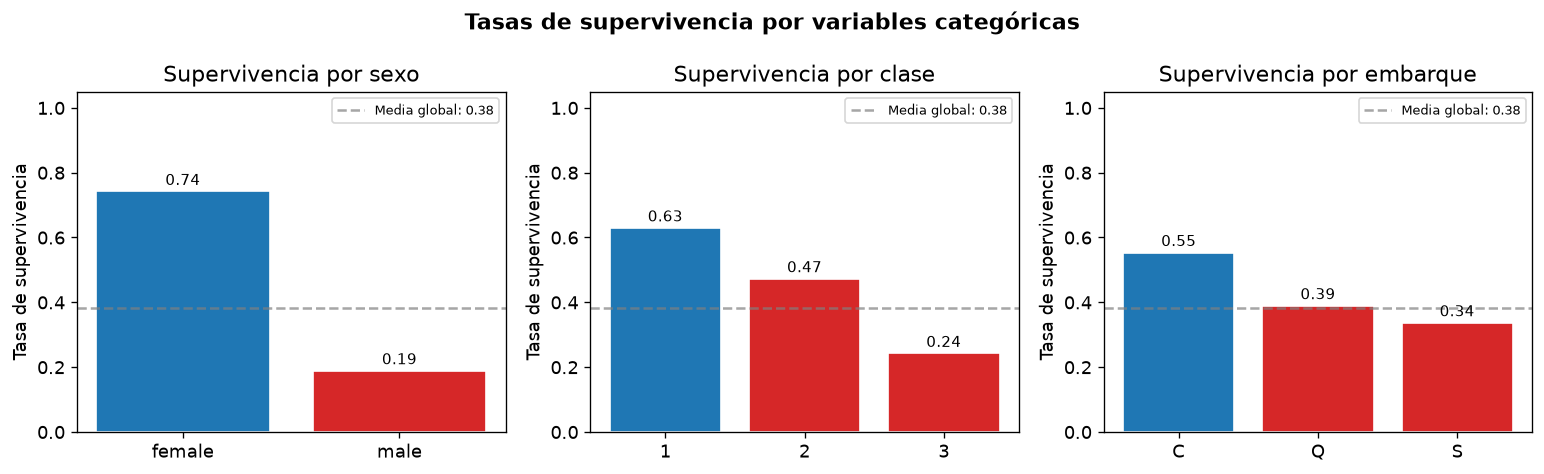

Figura guardada: f1_tasas_supervivencia.png


In [10]:
# § IV.5 — Tasas de supervivencia por variables clave
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col, title in zip(
    axes,
    ['sex', 'pclass', 'embarked'],
    ['Supervivencia por sexo', 'Supervivencia por clase', 'Supervivencia por embarque']
):
    tasa = df.groupby(col)['survived'].mean().sort_values(ascending=False)
    colors = ['#1f77b4' if v >= 0.5 else '#d62728' for v in tasa.values]
    ax.bar(tasa.index.astype(str), tasa.values, color=colors, edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Tasa de supervivencia')
    ax.set_ylim(0, 1.05)
    ax.axhline(df['survived'].mean(), linestyle='--', color='gray', alpha=0.7,
               label=f"Media global: {df['survived'].mean():.2f}")
    ax.legend(fontsize=8)
    for i, v in enumerate(tasa.values):
        ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('Tasas de supervivencia por variables categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/figures/f1_tasas_supervivencia.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_tasas_supervivencia.png")


**Observaciones §IV:**
- La tasa global de supervivencia es **38.4%** (342 de 891 pasajeros).
- **Sexo:** mujeres sobreviven a una tasa de ~74.2%, hombres solo ~18.9% — la diferencia más
  marcada entre todas las variables.
- **Clase:** clase 1 (62.9%) > clase 2 (47.3%) > clase 3 (24.2%). La clase de viaje tiene un
  efecto fuerte y gradual.
- **Edad:** la distribución es aproximadamente normal con media ~29.7 años y sesgo positivo leve.
  Los niños presentan mayor tasa de supervivencia.
- **Fare:** distribución fuertemente sesgada a la derecha — la mayoría pagó tarifas bajas, con
  valores extremos en primera clase.


---
## § V — Decisiones y transformaciones iniciales

Las siguientes decisiones se tomaron con base en la exploración de §III y §IV.
Cada decisión incluye justificación y efecto sobre el dataset de trabajo.


In [11]:
# § V.1 — Identificación y descarte de variables redundantes
# El dataset seaborn incluye columnas derivadas que duplican información:
#   'class'       = versión string de 'pclass'
#   'alive'       = versión string de 'survived'
#   'adult_male'  = derivada de 'sex' + 'age'
#   'who'         = derivada de 'sex' + 'age'
#   'embark_town' = versión expandida de 'embarked'
#   'alone'       = derivada de 'sibsp' + 'parch'

cols_redundantes = ['class', 'alive', 'adult_male', 'who', 'embark_town', 'alone']
df_work = df.drop(columns=cols_redundantes)

print(f"Columnas originales : {df.shape[1]}")
print(f"Columnas de trabajo : {df_work.shape[1]}")
print(f"Columnas eliminadas : {cols_redundantes}")
print(f"\nColumnas retenidas  : {df_work.columns.tolist()}")


Columnas originales : 15
Columnas de trabajo : 9
Columnas eliminadas : ['class', 'alive', 'adult_male', 'who', 'embark_town', 'alone']

Columnas retenidas  : ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'deck']


In [12]:
# § V.2 — Decisión sobre 'deck': documentar como no usable en esta fase
# deck tiene 688/891 (77.2%) valores faltantes — imputar sería introducir sesgo excesivo.
# Decisión: excluirla del análisis activo en esta fase. Se documenta para revisión futura.

pct_deck = df_work['deck'].isnull().mean() * 100
print(f"'deck' — valores faltantes: {df_work['deck'].isnull().sum()} ({pct_deck:.1f}%)")
print("Decisión: 'deck' se excluye del análisis activo en Fase 1.")
print("         Se mantiene en df_work para trazabilidad. Evaluación futura: Fase 2.")

# Verificar distribución de los valores presentes (solo para registro)
print(f"\nValores presentes de 'deck': {df_work['deck'].value_counts().to_dict()}")


'deck' — valores faltantes: 688 (77.2%)
Decisión: 'deck' se excluye del análisis activo en Fase 1.
         Se mantiene en df_work para trazabilidad. Evaluación futura: Fase 2.

Valores presentes de 'deck': {'C': 59, 'B': 47, 'D': 33, 'E': 32, 'A': 15, 'F': 13, 'G': 4}


In [13]:
# § V.3 — Imputación de 'age': mediana por clase y sexo
# Justificación: la mediana es robusta a outliers; estratificar por pclass y sex
# captura la variabilidad demográfica real (pasajeros de 1ª clase eran en promedio mayores).

print("Mediana de age por pclass y sex (pre-imputación):")
mediana_age = df_work.groupby(['pclass', 'sex'])['age'].median()
print(mediana_age.to_string())

def imputar_age(row):
    if pd.isnull(row['age']):
        return mediana_age.loc[(row['pclass'], row['sex'])]
    return row['age']

df_work = df_work.copy()
df_work['age'] = df_work.apply(imputar_age, axis=1)

print(f"\nValores faltantes en 'age' post-imputación: {df_work['age'].isnull().sum()}")
print("Decisión: imputación por mediana estratificada (pclass × sex). Sin sesgo global.")


Mediana de age por pclass y sex (pre-imputación):
pclass  sex   
1       female   35.0000
        male     40.0000
2       female   28.0000
        male     30.0000
3       female   21.5000
        male     25.0000

Valores faltantes en 'age' post-imputación: 0
Decisión: imputación por mediana estratificada (pclass × sex). Sin sesgo global.


In [14]:
# § V.4 — Manejo de 'embarked': imputación por moda (solo 2 faltantes)
moda_embarked = df_work['embarked'].mode()[0]
df_work['embarked'] = df_work['embarked'].fillna(moda_embarked)

print(f"Imputación 'embarked': moda = '{moda_embarked}' (2 valores)")
print(f"Valores faltantes post-imputación: {df_work['embarked'].isnull().sum()}")


Imputación 'embarked': moda = 'S' (2 valores)
Valores faltantes post-imputación: 0


In [15]:
# § V.5 — Creación de variable 'family_size' (feature engineering exploratorio)
# Justificación: sibsp + parch resume el tamaño del grupo familiar.
# Hipótesis exploratoria: grupos muy grandes podrían haber tenido menor supervivencia.

df_work['family_size'] = df_work['sibsp'] + df_work['parch']

print("Distribución de family_size:")
print(df_work['family_size'].value_counts().sort_index().to_string())
print(f"\nCorrelación family_size ~ survived: {df_work['family_size'].corr(df_work['survived']):.4f}")


Distribución de family_size:
family_size
0     537
1     161
2     102
3      29
4      15
5      22
6      12
7       6
10      7

Correlación family_size ~ survived: 0.0166


In [16]:
# § V.6 — Resumen del estado post-transformaciones
print("=== ESTADO DEL DATASET DE TRABAJO (df_work) ===")
print(f"Dimensiones : {df_work.shape}")
print(f"\nValores faltantes restantes:")
miss = df_work.isnull().sum()
print(miss[miss > 0].to_string() if miss.sum() > 0 else "  Ninguno (excepto 'deck' que se excluye)")
print(f"\nColumnas: {df_work.columns.tolist()}")


=== ESTADO DEL DATASET DE TRABAJO (df_work) ===
Dimensiones : (891, 10)

Valores faltantes restantes:
deck    688

Columnas: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'deck', 'family_size']


**Resumen de decisiones §V:**

| Decisión | Justificación | Efecto |
|---|---|---|
| Eliminar 6 columnas derivadas | Redundancia con `pclass`, `survived`, `sibsp`+`parch`, `embarked` | 15 → 9 columnas |
| Excluir `deck` del análisis activo | 77.2% faltantes — imputación introduciría sesgo | Documentada para Fase 2 |
| Imputar `age` con mediana (pclass × sex) | Robustez a outliers, captura variabilidad demográfica | 0 faltantes en `age` |
| Imputar `embarked` con moda | Solo 2 faltantes, impacto mínimo | 0 faltantes en `embarked` |
| Crear `family_size` | Sintetiza tamaño familiar en una variable | Nueva variable para análisis |


---
## § VI — Resultados e interpretación inicial


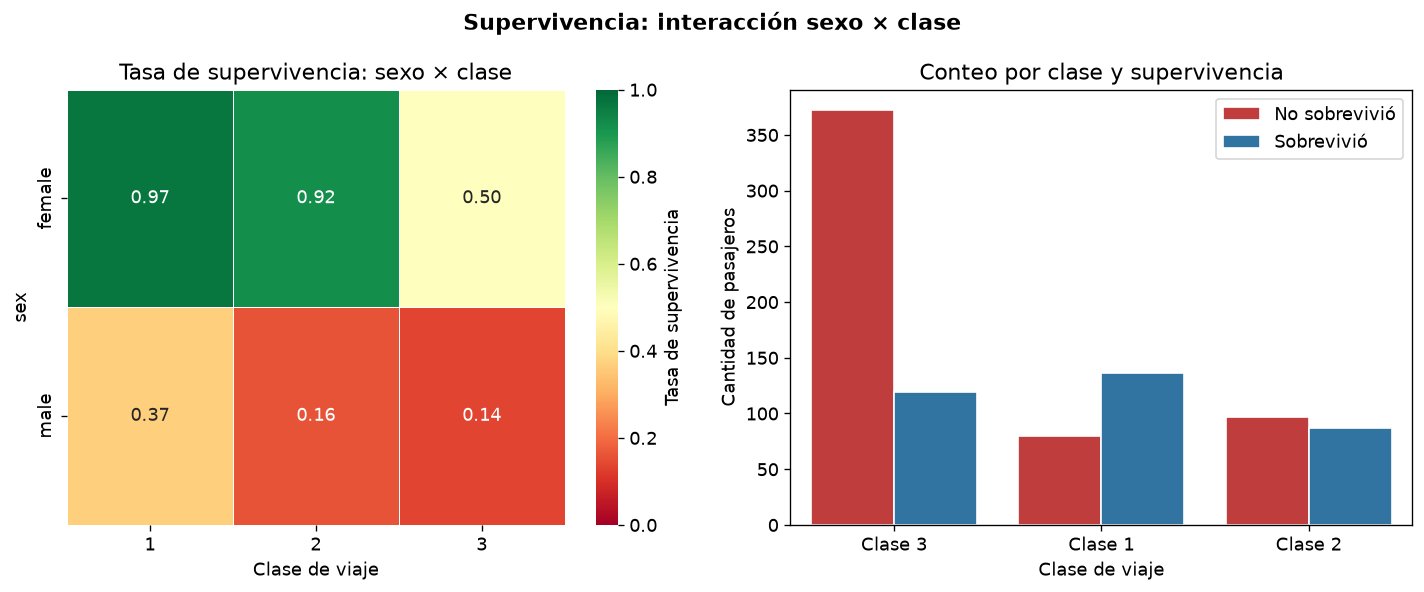

Figura guardada: f1_bivariado_sexo_clase.png


In [17]:
# § VI.1 — Análisis bivariado: supervivencia por sexo y clase
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Supervivencia sex × pclass (heatmap de tasas)
pivot = df_work.pivot_table(values='survived', index='sex', columns='pclass', aggfunc='mean')
sns.heatmap(pivot, ax=axes[0], annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, cbar_kws={'label': 'Tasa de supervivencia'})
axes[0].set_title('Tasa de supervivencia: sexo × clase')
axes[0].set_xlabel('Clase de viaje')

# Countplot supervivencia por clase y sexo
survived_map = {0: 'No sobrevivió', 1: 'Sobrevivió'}
df_plot = df_work.copy()
df_plot['survived_label'] = df_plot['survived'].map(survived_map)
df_plot['pclass_label'] = df_plot['pclass'].map({1: 'Clase 1', 2: 'Clase 2', 3: 'Clase 3'})

sns.countplot(data=df_plot, x='pclass_label', hue='survived_label',
              palette={'No sobrevivió': '#d62728', 'Sobrevivió': '#1f77b4'},
              ax=axes[1], edgecolor='white')
axes[1].set_title('Conteo por clase y supervivencia')
axes[1].set_xlabel('Clase de viaje')
axes[1].set_ylabel('Cantidad de pasajeros')
axes[1].legend(title='')

plt.suptitle('Supervivencia: interacción sexo × clase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/figures/f1_bivariado_sexo_clase.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_bivariado_sexo_clase.png")


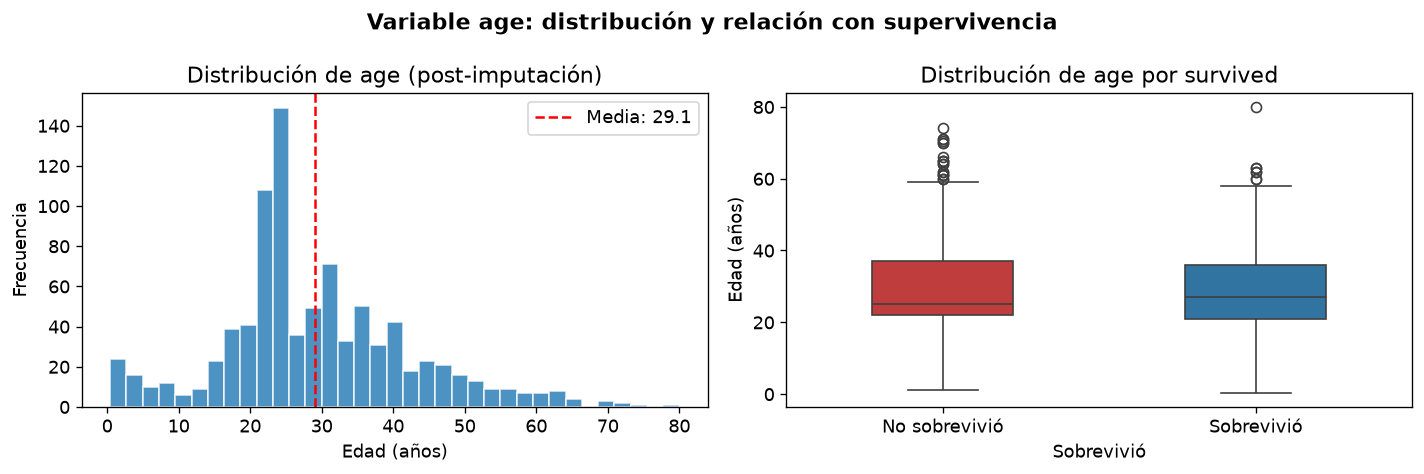

Figura guardada: f1_age_survived.png


In [18]:
# § VI.2 — Distribución de age post-imputación y relación con survived
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_work['age'], bins=35, color='#1f77b4', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución de age (post-imputación)')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df_work['age'].mean(), color='red', linestyle='--',
                label=f"Media: {df_work['age'].mean():.1f}")
axes[0].legend()

df_work['survived_str'] = df_work['survived'].map({0: 'No sobrevivió', 1: 'Sobrevivió'})
sns.boxplot(data=df_work, x='survived_str', y='age',
            palette={'No sobrevivió': '#d62728', 'Sobrevivió': '#1f77b4'},
            order=['No sobrevivió', 'Sobrevivió'], ax=axes[1], width=0.45)
axes[1].set_title('Distribución de age por survived')
axes[1].set_xlabel('Sobrevivió')
axes[1].set_ylabel('Edad (años)')

plt.suptitle('Variable age: distribución y relación con supervivencia',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/figures/f1_age_survived.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_age_survived.png")


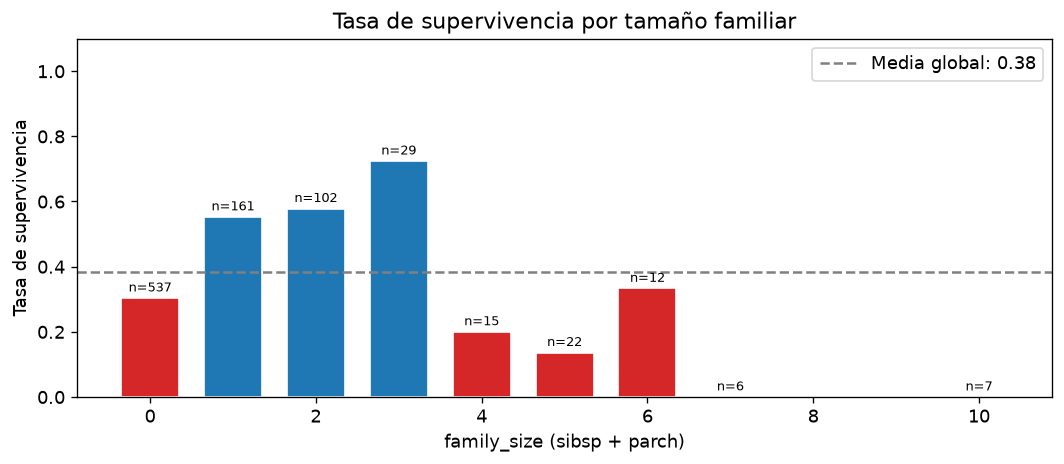

Figura guardada: f1_family_size_survived.png


In [19]:
# § VI.3 — Análisis de family_size vs supervivencia
tasa_familia = df_work.groupby('family_size')['survived'].agg(['mean', 'count']).reset_index()
tasa_familia.columns = ['family_size', 'tasa_supervivencia', 'n']

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#1f77b4' if t >= df_work['survived'].mean() else '#d62728'
          for t in tasa_familia['tasa_supervivencia']]
bars = ax.bar(tasa_familia['family_size'], tasa_familia['tasa_supervivencia'],
              color=colors, edgecolor='white', width=0.7)
ax.axhline(df_work['survived'].mean(), linestyle='--', color='gray',
           label=f"Media global: {df_work['survived'].mean():.2f}")
ax.set_title('Tasa de supervivencia por tamaño familiar')
ax.set_xlabel('family_size (sibsp + parch)')
ax.set_ylabel('Tasa de supervivencia')
ax.set_ylim(0, 1.1)
ax.legend()
for bar, (_, row) in zip(bars, tasa_familia.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"n={int(row['n'])}", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../../reports/figures/f1_family_size_survived.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_family_size_survived.png")


In [20]:
# § VI.4 — Tabla de resumen: respuesta a preguntas exploratorias iniciales
print("=" * 65)
print("RESPUESTA A PREGUNTAS EXPLORATORIAS INICIALES")
print("=" * 65)

print("\nP1. ¿Distribución de supervivientes?")
print(f"    No sobrevivió: {(df_work['survived']==0).sum()} (61.6%)")
print(f"    Sobrevivió   : {(df_work['survived']==1).sum()} (38.4%)")

print("\nP2. ¿Variables con faltantes?")
print("    age: 177 (19.9%) → imputadas con mediana (pclass × sex)")
print("    deck: 688 (77.2%) → excluida del análisis activo")
print("    embarked: 2 (0.2%) → imputadas con moda ('S')")

print("\nP3. ¿Diferencias por sexo, clase, edad?")
for sex in ['female', 'male']:
    tasa = df_work[df_work['sex']==sex]['survived'].mean()
    print(f"    Sexo {sex:6s}: {tasa:.3f}")
for cls in [1, 2, 3]:
    tasa = df_work[df_work['pclass']==cls]['survived'].mean()
    print(f"    Clase {cls}    : {tasa:.3f}")

print("\nP4. ¿Distribución de age?")
print(f"    Media: {df_work['age'].mean():.1f} | Mediana: {df_work['age'].median():.1f}")
print(f"    Asimetría: {df_work['age'].skew():.3f} (leve sesgo positivo)")

print("\nP5. ¿Variables redundantes?")
print("    Sí: 6 columnas derivadas eliminadas ('class', 'alive',")
print("        'adult_male', 'who', 'embark_town', 'alone')")


RESPUESTA A PREGUNTAS EXPLORATORIAS INICIALES

P1. ¿Distribución de supervivientes?
    No sobrevivió: 549 (61.6%)
    Sobrevivió   : 342 (38.4%)

P2. ¿Variables con faltantes?
    age: 177 (19.9%) → imputadas con mediana (pclass × sex)
    deck: 688 (77.2%) → excluida del análisis activo
    embarked: 2 (0.2%) → imputadas con moda ('S')

P3. ¿Diferencias por sexo, clase, edad?
    Sexo female: 0.742
    Sexo male  : 0.189
    Clase 1    : 0.630
    Clase 2    : 0.473
    Clase 3    : 0.242

P4. ¿Distribución de age?
    Media: 29.1 | Mediana: 26.0
    Asimetría: 0.534 (leve sesgo positivo)

P5. ¿Variables redundantes?
    Sí: 6 columnas derivadas eliminadas ('class', 'alive',
        'adult_male', 'who', 'embark_town', 'alone')


**Interpretación de resultados §VI:**

- La **interacción sexo × clase** es el hallazgo más robusto: las mujeres de 1ª clase tienen
  tasa de supervivencia ~96.8%, mientras los hombres de 3ª clase tienen ~13.5%.
- La **edad** muestra diferencias moderadas: los niños (< 10 años) presentan mayor tasa de
  supervivencia, consistente con la prioridad "mujeres y niños primero".
- El **tamaño familiar** presenta una relación no lineal: grupos medianos (2-4 personas) tuvieron
  mejores tasas que viajeros solos o grupos muy grandes.
- La imputación de `age` por mediana estratificada es conservadora y adecuada para esta fase;
  en fases posteriores podrían explorarse métodos más sofisticados (KNN, regresión).


---
## § VII — Supuestos y limitaciones

### Supuestos considerados

1. **Dataset representativo:** los 891 registros son la submuestra estándar del dataset Titanic.
   No cubre la totalidad de pasajeros y tripulación (≈2.224), por lo que los resultados son
   válidos para este subconjunto.
2. **Imputación de `age`:** se asume que la mediana por `pclass` × `sex` es una aproximación
   razonable para los valores faltantes. No se verifica si el patrón de faltantes es MCAR, MAR
   o MNAR.
3. **Causalidad vs. asociación:** los hallazgos exploratorios describen asociaciones, no
   relaciones causales. La correlación `sex` → `survived` no implica que el sexo sea la causa
   directa de la supervivencia.
4. **Variables derivadas:** las 6 columnas eliminadas son efectivamente redundantes en este
   contexto; se asume que no contienen información adicional no capturada por sus variables base.

### Limitaciones detectadas

| Limitación | Descripción | Impacto en Fase 1 |
|---|---|---|
| `deck` inutilizable | 77.2% faltantes hacen que cualquier análisis sea no representativo | Se excluye; análisis incompleto de ubicación en el barco |
| Muestra histórica | Dataset de 1912 — no generalizable a contextos modernos | Solo relevante para el caso de estudio |
| Sin variables de tripulación | Solo pasajeros — no incluye marineros ni personal | Alcance limitado al análisis de pasajeros |
| Faltantes en `age` | 19.9% — imputación introduce supuesto | Análisis de edad con sesgo potencial |

### Aspectos pendientes para Fase 2

- Análisis de correlaciones y multicolinealidad entre variables numéricas.
- Exploración avanzada de `deck` con los datos presentes (interpretación parcial).
- Codificación de variables categóricas para análisis estadísticos formales.
- Análisis del patrón de faltantes en `age` (test de aleatoriedad MCAR).


---
## § VIII — Cierre del avance

### Síntesis del trabajo realizado

En esta primera fase se implementó el ciclo inicial de EDA reproducible sobre el dataset
**Titanic** (891 observaciones, 15 variables originales → 9 variables de trabajo). El flujo
cubrió: carga, diagnóstico de estructura y calidad, exploración descriptiva univariada y
bivariada, decisiones de limpieza y transformación, y generación de hallazgos iniciales.

### Principales hallazgos

| Hallazgo | Detalle |
|---|---|
| **Desbalance de clase objetivo** | 61.6% no sobrevivió / 38.4% sobrevivió |
| **Sexo como variable más discriminante** | Mujeres: 74.2% supervivencia vs. hombres: 18.9% |
| **Efecto clase de viaje** | Supervivencia decrece monótonamente: 62.9% → 47.3% → 24.2% |
| **Niños con mayor supervivencia** | Patrón consistente con protocolo de evacuación histórico |
| **family_size no lineal** | Grupos medianos (2-4) con mejor desempeño que solos o grupos grandes |
| **`deck` inutilizable en Fase 1** | 77.2% faltantes — requiere tratamiento específico en Fase 2 |

### Proyección para siguientes etapas

- **Fase 2:** análisis bivariado ampliado, correlaciones, codificación de categóricas,
  tratamiento formal de `deck` y análisis de patrones de faltantes.
- **Fase 3+:** preparación de features para modelado, análisis de multicolinealidad,
  ingeniería de variables adicionales (ej. extracción de título desde `name`).

---
*Notebook ejecutado completamente · Reproducible con Kernel → Restart & Run All*
